In [45]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

Tucker Decomposition (d = 3) case (HOSVD)

step 1: unfold the tensor

given a rank 3 tensor, we can think of it taking a shape of a cube, being characterized by depth/height/width (labed as I,J,K paramters.) Giving us (IxJxK) tensor components. We aim to flatten the matrix by finding 3 matrices, which each holds information of the tensor's rows, columns and depths. 

Thus we consider 3 different tensor slicing to collect the rows, columns and depths to give us the T1, T2, T3 matrices.

In [10]:
#randomized rank 3 tensor, with i,j,k randomly assigned between 1-10, and tensor entires between 1-50
def rand_tensor():
    i = 3
    j = np.random.randint(3, 11)
    k = np.random.randint(3, 11)
    
    tensor = np.random.randint(0, 51, size=(i, j, k))

    return tensor

In [20]:
def flatten(tensor):
    i,j,k = np.shape(tensor) #returns tuple (i,j,k)

    T1 = tensor.transpose(0, 2, 1).reshape(i, -1)
    T2 = tensor.transpose(1, 2, 0).reshape(j, -1)
    T3 = tensor.transpose(2, 1, 0).reshape(k, -1)

    #tensor transpose rotates the tensor into its different sides, and 
    #reshape reduces the dimension of the tensor, which in this case flattens it into a matrix.
    return T1, T2, T3

Here we have successfully collected all the rows, columns and depths vectors.

Step 2:
Now that we have the unfolded matrices, we can perform SVD on them to obtain U1, U2, and U3 (U part of the SVD, A = U sigma VTranspose)

In [105]:
def factor_matrices(T1, T2, T3):
    U1, S1, Vt1 = np.linalg.svd(T1, full_matrices=False)
    U2, S2, Vt2 = np.linalg.svd(T2, full_matrices=False)
    U3, S3, Vt3 = np.linalg.svd(T3, full_matrices=False) 
    #we keep singular values here, so that we could ignore some of these entires to simplify calculation when we have larger matrices
    return U1, U2, U3

In [106]:
def core_tensor(tensor, U1, U2, U3):
    X_step1 = np.tensordot(tensor, U1, axes=(0, 0))
    X_step2 = np.tensordot(X_step1, U2, axes=(0, 0))
    X = np.tensordot(X_step2, U3, axes=(0, 0))
    return X

In [107]:
def reconstruct(X, U1, U2, U3):
    A_step1 = np.tensordot(X, U1, axes=(0, 1))
    A_step2 = np.tensordot(A_step1, U2, axes=(0, 1))
    A = np.tensordot(A_step2, U3, axes=(0, 1))
    return A

In [108]:
print(T)

[[[ 8 38 22 28 11  1 29 32]
  [50 43 31  2 39 37 37  9]
  [ 6 46  0 42 28 39 13 49]
  [45 39 39 22 18 26 39 11]
  [42 44 19 16  0 41 50 14]
  [18 18 42 22 39 31 17 41]
  [18 16 30  3 21 46  1 21]
  [43 50  0 45 45 33 46 47]
  [24 28 22 19 46  3 17 30]
  [44 28 11 43 32 21 48 11]]

 [[31 43 22  6 20 10  9 30]
  [12 41  1 38 22 36 43 36]
  [20 31  5 25 43 46 19 24]
  [32 31 43 30  0 41 12 35]
  [26 38 40 41 12 28 22 45]
  [15 31 33 19 50 19  7  2]
  [ 1 24 44 18 35 48  2 39]
  [20 17 39 45 15 16 16 41]
  [39 27 14  3 11  6 43 14]
  [48 18 50 16 22 31 10 13]]

 [[26 40 21 23  3 11 20 27]
  [33 25 49 14  9 48  1 33]
  [28 27 40 37 26 45  9 11]
  [23  2 47  2  8 10 37  5]
  [25 19  2  4 47 35 40  6]
  [10 28 33 12  9 21 29 33]
  [46 19 27 17 12  4  6 39]
  [40 10 40 43  7 17  1 42]
  [23 38  4 50 50  2  7 17]
  [28 37 32 21 22 19 49 19]]]


In [123]:
T1, T2, T3 = flatten(T)
U1,U2,U3 = factor_matrices(T1,T2,T3)
X = core_tensor(T, U1,U2,U3)

A = reconstruct(X,U1,U2,U3)

In [124]:
error_tucker = np.linalg.norm(T-A)
relative_error_tucker = error_tucker/np.linalg.norm(T)
print(relative_error_tucker)

8.566135881033826e-16


In [114]:
tucker_memory_bytes = X.nbytes + U1.nbytes + U2.nbytes + U3.nbytes

In [115]:
print(tucker_memory_bytes)

3304


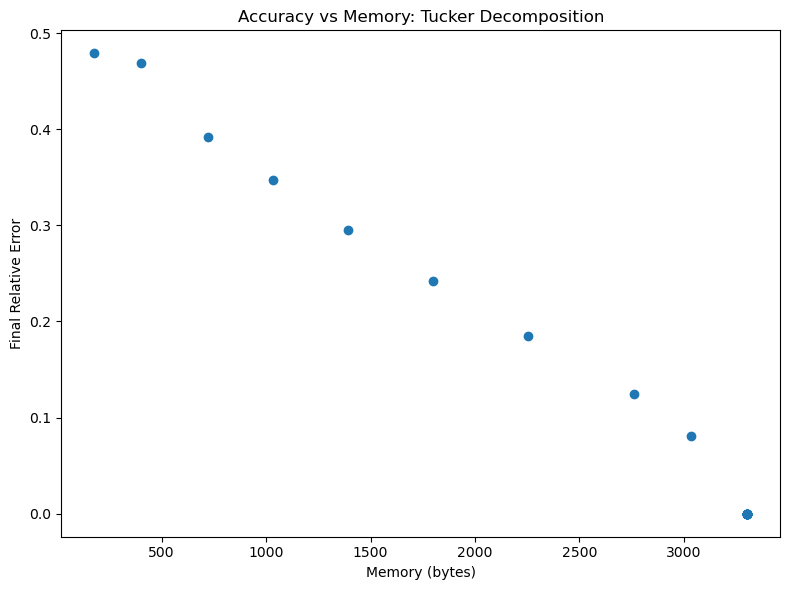

In [128]:
ranks = range(1, 21)
tucker_memory = []
tucker_accuracy = []

for r in ranks:
    # Truncate factor matrices to rank r
    U1r = U1[:, :r]
    U2r = U2[:, :r]
    U3r = U3[:, :r]
    
    # Compute core tensor and reconstruct
    Xr = core_tensor(T, U1r, U2r, U3r)
    Ar = reconstruct(Xr, U1r, U2r, U3r)
    
    # Error
    error = np.linalg.norm(T - Ar) / np.linalg.norm(T)
    tucker_accuracy.append(error)
    
    # Memory
    mem = Xr.nbytes + U1r.nbytes + U2r.nbytes + U3r.nbytes
    tucker_memory.append(mem)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(tucker_memory, tucker_accuracy, "o")

plt.xlabel("Memory (bytes)")
plt.ylabel("Final Relative Error")
plt.title("Accuracy vs Memory: Tucker Decomposition")
plt.tight_layout()
plt.show()

In [213]:
print(tucker_memory)
print(tucker_accuracy)

[176, 400, 720, 1032, 1392, 1800, 2256, 2760, 3032, 3304, 3304, 3304, 3304, 3304, 3304, 3304, 3304, 3304, 3304, 3304]
[np.float64(0.47897204540722255), np.float64(0.4684972978097143), np.float64(0.39174560770935984), np.float64(0.34679078981986144), np.float64(0.29550550321557295), np.float64(0.2424424481877646), np.float64(0.185041310769907), np.float64(0.12451063351603359), np.float64(0.08073617486810704), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16), np.float64(8.566135881033826e-16)]


Example:

In [36]:
tensor = rand_tensor()
print(tensor)

[[[ 5 24]
  [46 43]
  [27 22]
  [28  3]]

 [[ 3 35]
  [34 44]
  [29 19]
  [38 11]]

 [[ 0 41]
  [36 30]
  [18 41]
  [18 23]]]


In [43]:
T1, T2, T3 = flatten(tensor)
print(T1)
print(T2)
print(T3)

[[ 5 46 27 28 24 43 22  3]
 [ 3 34 29 38 35 44 19 11]
 [ 0 36 18 18 41 30 41 23]]
[[ 5 24  3 35  0 41]
 [46 43 34 44 36 30]
 [27 22 29 19 18 41]
 [28  3 38 11 18 23]]
[[ 5  3  0 46 34 36 27 29 18 28 38 18]
 [24 35 41 43 44 30 22 19 41  3 11 23]]


In [50]:
U1, U2, U3 = factor_matrices(T1, T2, T3)
X = core_tensor(tensor, U1, U2, U3)

A = reconstruct(X,U1,U2,U3)
print(A)

[[[ 5.00000000e+00  2.40000000e+01]
  [ 4.60000000e+01  4.30000000e+01]
  [ 2.70000000e+01  2.20000000e+01]
  [ 2.80000000e+01  3.00000000e+00]]

 [[ 3.00000000e+00  3.50000000e+01]
  [ 3.40000000e+01  4.40000000e+01]
  [ 2.90000000e+01  1.90000000e+01]
  [ 3.80000000e+01  1.10000000e+01]]

 [[-5.58626961e-15  4.10000000e+01]
  [ 3.60000000e+01  3.00000000e+01]
  [ 1.80000000e+01  4.10000000e+01]
  [ 1.80000000e+01  2.30000000e+01]]]


Combine into the final HOSVD function:

In [51]:
def HOSVD(A):
    T1, T2, T3 = flatten(A)
    U1, U2, U3 = factor_matrices(T1, T2, T3)
    X = core_tensor(tensor, U1, U2, U3)
    A = reconstruct(X,U1,U2,U3)
    return A

Note that this method can be generalized for rank d tensors, by having T1,T2,...,Td and following the same steps.

references for this part:
https://en.wikipedia.org/wiki/Higher-order_singular_value_decomposition
https://www.math.ucdavis.edu/~saito/data/tensor/lathauwer-etal_mulilinear-SVD.pdf (good diagram)
https://www.math.ucdavis.edu/~saito/data/tensor/bergqvist-larsson-hosvd.pdf (good visuals/short poster)

extra reference along-side wiki on HOSVD: https://www.math.ucdavis.edu/~saito/data/tensor/kolda-bader_tensor-decomp-siamrev.pdf

CP Decomposition:

In [21]:
def khatrirao(A,B):
    num_cols = A.shape[1]
    columns = [np.kron(A[:, i], B[:, i]) for i in range(num_cols)]
    return np.column_stack(columns)

In [22]:
def hadamard(A,B):
    return A * B

In [23]:
def optimize_a(T1,B,C):
    hold = hadamard(C.T@C, B.T@B)
    A = T1 @ khatrirao(C,B)
    A = A @ np.linalg.pinv(hold)
    return A

In [24]:
def optimize_b(T2,C,A):
    hold = hadamard(C.T@C, A.T@A)
    B = T2 @ khatrirao(C,A)
    B = B @ np.linalg.pinv(hold)
    return B

In [25]:
def optimize_c(T3, B, A):
    hold = hadamard(B.T@B, A.T@A)
    C = T3 @ khatrirao(B,A)
    C = C @ np.linalg.pinv(hold)
    return C

In [30]:
def CP(tensor, rank, max_iter, tol=1e-4):
    i,j,k = np.shape(tensor)
    T1, T2, T3 = flatten(tensor)
    A = np.random.random((i, rank))
    B = np.random.random((j, rank))
    C = np.random.random((k, rank))

    for iteration in range(max_iter):
        #A_old = A.copy()
        
        A = optimize_a(T1, B, C)
        B = optimize_b(T2, C, A)
        C = optimize_c(T3, B, A)

        #change = np.linalg.norm(A - A_old)
        #if change < tol:
        #    break
    return A,B,C

In [38]:
def reconstruct_CP(A, B, C):
    I, R = A.shape
    J, _ = B.shape
    K, _ = C.shape
    
    tensor = np.zeros((I, J, K))
    
    for i in range(R):
        a_col = A[:, i]
        b_col = B[:, i]
        c_col = C[:, i]
        
        rank1_component = a_col[:, None, None] * b_col[None, :, None] * c_col[None, None, :]
        tensor += rank1_component
    
    return tensor

In [47]:
def CP_convergence(tensor, rank, max_iter, tol=1e-4):
    data = np.array([])
    i,j,k = np.shape(tensor)
    T1, T2, T3 = flatten(tensor)
    A = np.random.random((i, rank))
    B = np.random.random((j, rank))
    C = np.random.random((k, rank))

    norm_T = np.linalg.norm(tensor)

    for iteration in range(max_iter):
        #A_old = A.copy()
        
        A = optimize_a(T1, B, C)
        B = optimize_b(T2, C, A)
        C = optimize_c(T3, B, A)
        X = reconstruct_CP(A,B,C)
        error = np.linalg.norm(tensor-X)
        relative_error = error/norm_T
        data = np.append(data,relative_error)

        #change = np.linalg.norm(A - A_old)
        #if change < tol:
        #    break
    return A,B,C, data

In [ ]:
diff = T - T_approx
frob_error = np.linalg.norm(diff)
    
# Relative Error (Standard in literature)
relative_error = frob_error / np.linalg.norm(T)
memory_bytes = u.nbytes + v.nbytes + w.nbytes + sigma.nbytes

In [40]:
T = rand_tensor()
print(T)

[[[ 8 38 22 28 11  1 29 32]
  [50 43 31  2 39 37 37  9]
  [ 6 46  0 42 28 39 13 49]
  [45 39 39 22 18 26 39 11]
  [42 44 19 16  0 41 50 14]
  [18 18 42 22 39 31 17 41]
  [18 16 30  3 21 46  1 21]
  [43 50  0 45 45 33 46 47]
  [24 28 22 19 46  3 17 30]
  [44 28 11 43 32 21 48 11]]

 [[31 43 22  6 20 10  9 30]
  [12 41  1 38 22 36 43 36]
  [20 31  5 25 43 46 19 24]
  [32 31 43 30  0 41 12 35]
  [26 38 40 41 12 28 22 45]
  [15 31 33 19 50 19  7  2]
  [ 1 24 44 18 35 48  2 39]
  [20 17 39 45 15 16 16 41]
  [39 27 14  3 11  6 43 14]
  [48 18 50 16 22 31 10 13]]

 [[26 40 21 23  3 11 20 27]
  [33 25 49 14  9 48  1 33]
  [28 27 40 37 26 45  9 11]
  [23  2 47  2  8 10 37  5]
  [25 19  2  4 47 35 40  6]
  [10 28 33 12  9 21 29 33]
  [46 19 27 17 12  4  6 39]
  [40 10 40 43  7 17  1 42]
  [23 38  4 50 50  2  7 17]
  [28 37 32 21 22 19 49 19]]]


In [52]:
x = np.arange(len(data6))

In [103]:
A1, B1, C1, data1 = CP_convergence(T, 1, 100, tol=1e-4)
A2, B2, C2, data2 = CP_convergence(T, 2, 100, tol=1e-4)
A3, B3, C3, data3 = CP_convergence(T, 3, 100, tol=1e-4)
A4, B4, C4, data4 = CP_convergence(T, 4, 100, tol=1e-4)
A5, B5, C5, data5 = CP_convergence(T, 5, 100, tol=1e-4)
A6, B6, C6, data6 = CP_convergence(T, 6, 100, tol=1e-4)
A7, B7, C7, data7 = CP_convergence(T, 7, 100, tol=1e-4)
A8, B8, C8, data8 = CP_convergence(T, 8, 100, tol=1e-4)
A9, B9, C9, data9 = CP_convergence(T, 9, 100, tol=1e-4)
A10, B10, C10, data10 = CP_convergence(T, 10, 100, tol=1e-4)
A11, B11, C11, data11 = CP_convergence(T, 11, 100, tol=1e-4)
A12, B12, C12, data12 = CP_convergence(T, 12, 100, tol=1e-4)
A13, B13, C13, data13 = CP_convergence(T, 13, 100, tol=1e-4)
A14, B14, C14, data14 = CP_convergence(T, 14, 100, tol=1e-4)
A15, B15, C15, data15 = CP_convergence(T, 15, 100, tol=1e-4)
A16, B16, C16, data16 = CP_convergence(T, 16, 100, tol=1e-4)
A17, B17, C17, data17 = CP_convergence(T, 17, 100, tol=1e-4)
A18, B18, C18, data18 = CP_convergence(T, 18, 100, tol=1e-4)
A19, B19, C19, data19 = CP_convergence(T, 19, 100, tol=1e-4)
A20, B20, C20, data20 = CP_convergence(T, 20, 100, tol=1e-4)

rank1_memory_bytes  = A1.nbytes  + B1.nbytes  + C1.nbytes
rank2_memory_bytes  = A2.nbytes  + B2.nbytes  + C2.nbytes
rank3_memory_bytes  = A3.nbytes  + B3.nbytes  + C3.nbytes
rank4_memory_bytes  = A4.nbytes  + B4.nbytes  + C4.nbytes
rank5_memory_bytes  = A5.nbytes  + B5.nbytes  + C5.nbytes
rank6_memory_bytes  = A6.nbytes  + B6.nbytes  + C6.nbytes
rank7_memory_bytes  = A7.nbytes  + B7.nbytes  + C7.nbytes
rank8_memory_bytes  = A8.nbytes  + B8.nbytes  + C8.nbytes
rank9_memory_bytes  = A9.nbytes  + B9.nbytes  + C9.nbytes
rank10_memory_bytes = A10.nbytes + B10.nbytes + C10.nbytes
rank11_memory_bytes = A11.nbytes + B11.nbytes + C11.nbytes
rank12_memory_bytes = A12.nbytes + B12.nbytes + C12.nbytes
rank13_memory_bytes = A13.nbytes + B13.nbytes + C13.nbytes
rank14_memory_bytes = A14.nbytes + B14.nbytes + C14.nbytes
rank15_memory_bytes = A15.nbytes + B15.nbytes + C15.nbytes
rank16_memory_bytes = A16.nbytes + B16.nbytes + C16.nbytes
rank17_memory_bytes = A17.nbytes + B17.nbytes + C17.nbytes
rank18_memory_bytes = A18.nbytes + B18.nbytes + C18.nbytes
rank19_memory_bytes = A19.nbytes + B19.nbytes + C19.nbytes
rank20_memory_bytes = A20.nbytes + B20.nbytes + C20.nbytes

memory = np.array([
    rank1_memory_bytes,  rank2_memory_bytes,  rank3_memory_bytes,  rank4_memory_bytes,
    rank5_memory_bytes,  rank6_memory_bytes,  rank7_memory_bytes,  rank8_memory_bytes,
    rank9_memory_bytes,  rank10_memory_bytes, rank11_memory_bytes, rank12_memory_bytes,
    rank13_memory_bytes, rank14_memory_bytes, rank15_memory_bytes, rank16_memory_bytes,
    rank17_memory_bytes, rank18_memory_bytes, rank19_memory_bytes, rank20_memory_bytes
])

accuracy = np.array([
    data1[-1],  data2[-1],  data3[-1],  data4[-1],  data5[-1],
    data6[-1],  data7[-1],  data8[-1],  data9[-1],  data10[-1],
    data11[-1], data12[-1], data13[-1], data14[-1], data15[-1],
    data16[-1], data17[-1], data18[-1], data19[-1], data20[-1]
])

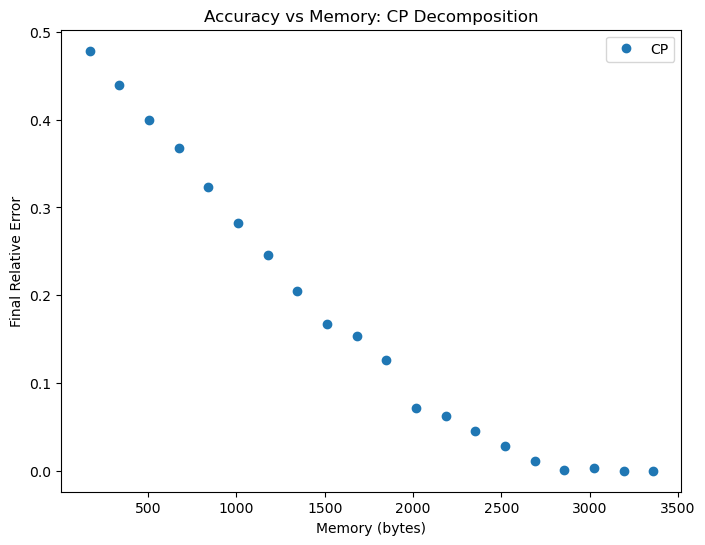

In [127]:
plt.figure(figsize=(8, 6))
plt.plot(memory,accuracy, "o",label="CP")
plt.legend()            
plt.xlabel("Memory (bytes)")
plt.ylabel("Final Relative Error")
plt.title("Accuracy vs Memory: CP Decomposition")
plt.show()

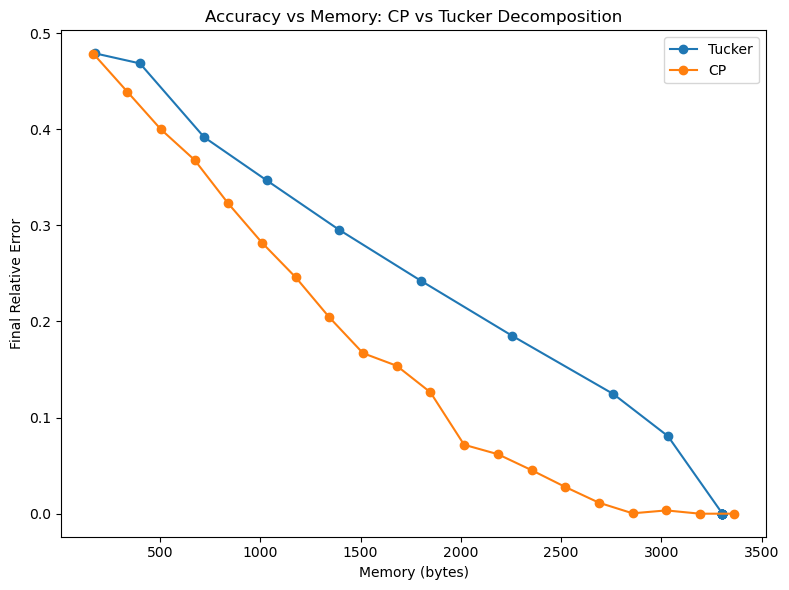

In [212]:
plt.figure(figsize=(8, 6))
plt.plot(tucker_memory, tucker_accuracy, "o-", label="Tucker")
plt.plot(memory, accuracy, "o-", label="CP")
plt.legend()
plt.xlabel("Memory (bytes)")
plt.ylabel("Final Relative Error")
plt.title("Accuracy vs Memory: CP vs Tucker Decomposition")
plt.tight_layout()
plt.show()

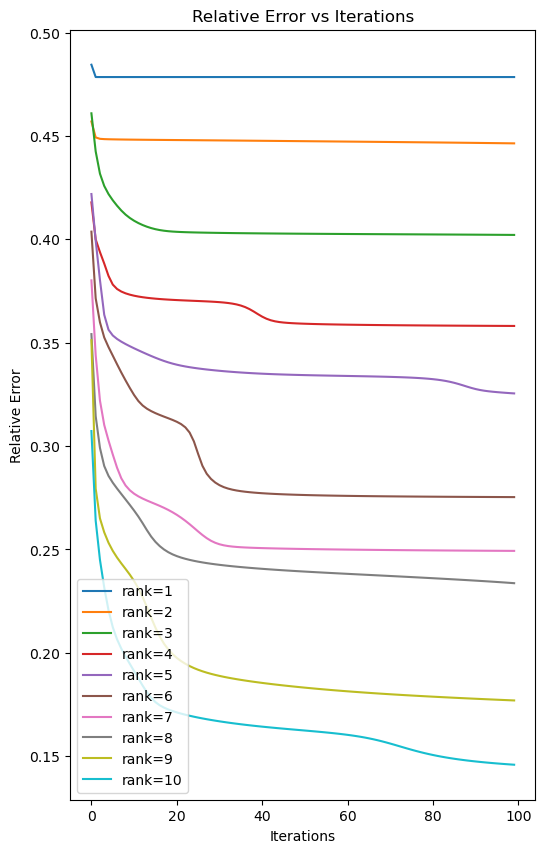

In [93]:
plt.figure(figsize=(6, 10))
plt.plot(x, data1, label="rank=1")
plt.plot(x, data2, label="rank=2")
plt.plot(x, data3, label="rank=3")
plt.plot(x, data4, label="rank=4")
plt.plot(x, data5, label="rank=5")
plt.plot(x, data6, label="rank=6")
plt.plot(x, data7, label="rank=7")
plt.plot(x, data8, label="rank=8")
plt.plot(x, data9, label="rank=9")
plt.plot(x, data10, label="rank=10")

plt.legend()            
plt.xlabel("Iterations")
plt.ylabel("Relative Error")         
plt.title("Relative Error vs Iterations")
plt.show()

Example:

In [36]:
tensor = rand_tensor()
print(tensor)

[[[49 48 20 30]
  [33 15 38  5]
  [46  0 48 35]
  [39 49 35  2]]

 [[28  3 46  6]
  [ 9 12 29  2]
  [20 27 27  4]
  [13 50 33 23]]

 [[41 28 22 44]
  [20 11 31 23]
  [25  7 29 23]
  [19 36  6  3]]]


In [76]:
A,B,C = CP(tensor, 5,100, 1e-4)
print(A)
print(B)
print(C)

[[13.68051212 17.12565491 39.39776144 33.7737343  -8.00895449]
 [ 9.69670908 -2.7811761  -3.56059073 31.68962907 12.85461262]
 [ 7.50726647  6.9039777  24.20482019 -8.61884572 -0.48499096]]
[[ 2.9388792  -0.90863981  1.34963287 -0.59638996 -0.08071789]
 [ 2.11041135 -0.47960289  0.2962909  -0.4589357  -0.51279064]
 [ 2.11168874 -0.04955963  0.30062702 -0.19628011 -0.98872989]
 [ 2.1456726  -2.55874086  1.18629673  0.21672995 -2.46211993]]
[[ 1.36355433  0.81689862  0.36149092  0.58751383  0.72628334]
 [ 0.29445706 -1.25343086  0.38691786  0.1269488  -1.69447927]
 [ 2.05795598  0.13682734 -0.82476922  0.85318895  0.64644747]
 [ 1.04814488  2.03959506  0.84077723  1.28485287  0.5963031 ]]


In [78]:
X = reconstruct_CP(A,B,C)
print(X)

[[[49.96741712 48.26438746 19.98936184 29.6146271 ]
  [30.75435431 14.38627098 38.09526573  5.85762438]
  [44.83639244 -0.10654794 49.03066601 34.71145146]
  [39.74626396 49.16828275 34.85810394  1.85097051]]

 [[27.3278288   2.72335167 46.160215    6.08171084]
  [15.28013451 13.26895532 26.49716007  0.66589654]
  [14.76114575 26.18926711 29.51824304  5.27271781]
  [13.70497959 50.07383614 32.6751957  22.72241262]]

 [[39.81685295 27.58554265 22.01384379 44.42424787]
  [23.99550357 11.67110354 29.77258873 21.11306434]
  [25.30953778  7.31457319 28.3297799  24.49594358]
  [17.68309615 35.73509883  6.22841026  3.30736798]]]


Definitions:
Rank of a tensor is given by the parameter sum(a_i o b_i o c_i) with the minimum i that best represents the tensor. 

A rank 1 tensor is given by a o b o c, where a,b,c are some columns vectors. 

Things to check:
Uniqueness of the decomposition? 
generalization into t_d tensors? (particularly for cp decomposition?)

Notice that we have 4 free parameters here, namely R, A, B, and C. In this particular example, I guessed the Rank of the tensor, and randomly generated A,B and C for this setup. 

If we don't know the rank of the tensor (which is usually the case), we can guess a max_rank and have the function iterate from i rank to max_rank, calculate the forbinus norm after performing ALS for each rank, and pick the rank that gives the best approximation. 

A seperate paper, https://arxiv.org/pdf/1410.6089, the authors offers a method to obtain a best rank 1 decomposition of a tensor by solving the least square problem using newton's method.

Newton1 Implementation:

Newton1 is a algorithm to find the best rank 1 approximation of a tensor using the newton's method (Newton-Raphson method).

In [141]:
def F(T,u,v,w): 
    x = np.einsum('ijk,j,k->i', T, v, w)
    y = np.einsum('ijk,i,k->j', T, u, w)
    z = np.einsum('ijk,i,j->k', T, u, v)
    return np.concatenate([x, y, z])

In [142]:
def G(T,u,v,w):
    return np.concatenate([u, v, w]) - F(T,u,v,w)

In [143]:
def DG(T,u,v,w):
    m, n, l = T.shape
    T_w = np.einsum('ijk,k->ij', T, w)
    T_v = np.einsum('ijk,j->ik', T, v)
    T_u = np.einsum('ijk,i->jk', T, u)

    Im = np.eye(m)
    In = np.eye(n)
    Il = np.eye(l)
    
    row1 = np.hstack([Im, -T_w, -T_v])
    row2 = np.hstack([-T_w.T, In, -T_u])
    row3 = np.hstack([-T_v.T, -T_u.T, Il])

    return np.vstack([row1, row2, row3])

In [144]:
def newton1(T,u,v,w):
    m, n, l = T.shape
    Gvector = G(T,u,v,w)
    DGmatrix = DG(T,u,v,w)
    hold = np.linalg.solve(DGmatrix, Gvector)

    long_vec = np.concatenate([u, v, w])-hold
    
    u = long_vec[:m]
    v = long_vec[m:m+n]
    w = long_vec[m+n:]
    return u,v,w

In [145]:
def initialize_newton1(T):
    T1, T2, T3 = flatten(T)
    
    u = np.linalg.svd(T1, full_matrices=False)[0][:, 0]
    v = np.linalg.svd(T2, full_matrices=False)[0][:, 0]
    w = np.linalg.svd(T3, full_matrices=False)[0][:, 0]

    u = np.abs(u)
    v = np.abs(v)
    w = np.abs(w)

    return u, v, w

In [151]:
def initialize_with_als(T, n_als=5):
    u, v, w = initialize_newton1(T)  # SVD init
    
    # warm up with a few ALS iterations
    for _ in range(n_als):
        u = np.einsum('ijk,j,k->i', T, v, w)
        u /= np.linalg.norm(u)
        v = np.einsum('ijk,i,k->j', T, u, w)
        v /= np.linalg.norm(v)
        w = np.einsum('ijk,i,j->k', T, u, v)
        w /= np.linalg.norm(w)
    return u, v, w

Example

In [167]:
T = rand_tensor()
print(T)

[[[ 8  5  9 25]
  [28 19 46  8]
  [30  6 45 28]
  [18 45 43 13]]

 [[21 19 21 31]
  [44  8 31  0]
  [15 31 38 19]
  [43 46 20 10]]

 [[41 35 12 29]
  [45 22  6 19]
  [23 34 16  8]
  [11 21 45 21]]]


In [152]:
m,n,l = T.shape

u,v,w = initialize_newton1(T)

for i in range(50):
    u,v,w = newton1(T,u,v,w)
    if i%10==0:
        err = np.linalg.norm(G(T, u, v, w))
        print(np.linalg.norm(G(T, u, v, w)))
        if err < 1e-12: # Stop early if converged
            break

u /= np.linalg.norm(u)
v /= np.linalg.norm(v)
w /= np.linalg.norm(w)
sigma = np.einsum('ijk,i,j,k->', T, u, v, w)
T_approx = sigma * np.einsum('i,j,k->ijk', u, v, w)

print(sigma)
print(T_approx)

173.75600790834145
2.6643342818456967e-05
8.185546896626418e-19
402.2729332244285
[[[25.13373591 27.14111059 23.74832464 21.72667133 21.25992856
   23.94587794 21.06139344 23.40674182]
  [33.73392911 36.42818178 31.87446159 29.16104446 28.53459293
   32.13961314 28.2681236  31.41599689]
  [31.84973407 34.39350035 30.09412637 27.53226605 26.94080473
   30.34446798 26.68921894 29.66126903]
  [29.50815521 31.86490487 27.88161903 25.5081056  24.96012825
   28.11355564 24.72703894 27.48058518]
  [32.00820537 34.56462838 30.24386247 27.66925539 27.07485119
   30.49544969 26.82201361 29.80885141]
  [28.06598455 30.3075513  26.5189431  24.26143188 23.74023618
   26.73954412 23.51853879 26.13750922]
  [26.12635932 28.21301259 24.68623308 22.58473726 22.09956111
   24.89158848 21.89318511 24.3311599 ]
  [34.98906437 37.78356186 33.06041181 30.24603681 29.59627696
   33.33542883 29.31989313 32.58488906]
  [25.81802735 27.88005484 24.39489685 22.31820197 21.83875167
   24.59782874 21.63481123 24.0

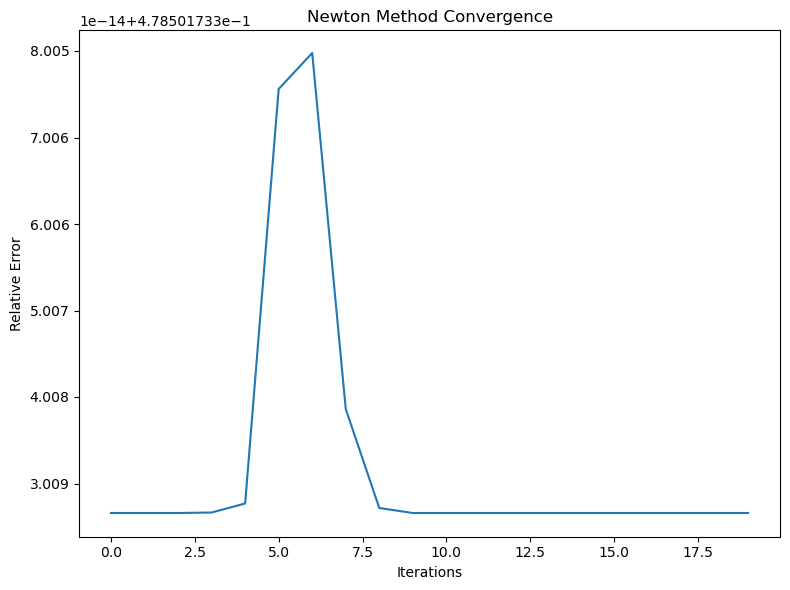

In [156]:
m, n, l = T.shape
u, v, w = initialize_with_als(T)
newton_err = np.array([])
norm_T = np.linalg.norm(T)

for i in range(20):
    u, v, w = newton1(T, u, v, w)
    
    # placeholder copies so we don't disturb u, v, w
    u_temp = u / np.linalg.norm(u)
    v_temp = v / np.linalg.norm(v)
    w_temp = w / np.linalg.norm(w)
    
    # reconstruct at this step
    sigma_temp = np.einsum('ijk,i,j,k->', T, u_temp, v_temp, w_temp)
    T_approx_temp = sigma_temp * np.einsum('i,j,k->ijk', u_temp, v_temp, w_temp)
    
    # relative error
    relative_error = np.linalg.norm(T - T_approx_temp) / norm_T
    newton_err = np.append(newton_err, relative_error)

# final rescale
u /= np.linalg.norm(u)
v /= np.linalg.norm(v)
w /= np.linalg.norm(w)
sigma = np.einsum('ijk,i,j,k->', T, u, v, w)
T_approx = sigma * np.einsum('i,j,k->ijk', u, v, w)

# plot
x = np.arange(20)
plt.figure(figsize=(8, 6))
plt.plot(x, newton_err)
plt.xlabel("Iterations")
plt.ylabel("Relative Error")
plt.title("Newton Method Convergence")
plt.tight_layout()
plt.show()

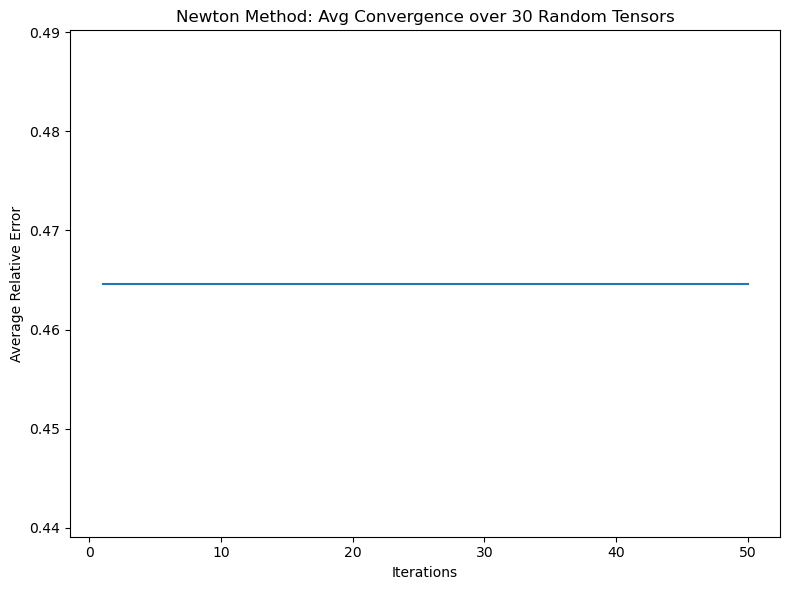

In [157]:
def run_newton(T, max_iter):
    u, v, w = initialize_with_als(T, n_als=20)
    norm_T = np.linalg.norm(T)
    errors = []
    for i in range(max_iter):
        u, v, w = newton1(T, u, v, w)
        u_t = u/np.linalg.norm(u)
        v_t = v/np.linalg.norm(v)
        w_t = w/np.linalg.norm(w)
        sig = np.einsum('ijk,i,j,k->', T, u_t, v_t, w_t)
        T_approx = sig * np.einsum('i,j,k->ijk', u_t, v_t, w_t)
        errors.append(np.linalg.norm(T - T_approx) / norm_T)
    return np.array(errors)

n_runs = 30
max_iter = 50
all_errors = np.zeros((n_runs, max_iter))

np.random.seed(42)
for r in range(n_runs):
    T = rand_tensor()
    all_errors[r] = run_newton(T, max_iter)

avg_errors = all_errors.mean(axis=0)

# plot
x = np.arange(1, max_iter+1)
plt.figure(figsize=(8, 6))
plt.plot(x, avg_errors)
plt.xlabel("Iterations")
plt.ylabel("Average Relative Error")
plt.title("Newton Method: Avg Convergence over 30 Random Tensors")
plt.tight_layout()
plt.show()

Computation of the matrix DG is O(n^3), and thus the complexity of each iteration of newton1 is O(n^3)

Explain einstein notation used in the code!

## Just test the different tensor decompositions, their convergence rate, storage, computational time, and forbinus norm things. run at least 50 different times and obtain data.

In [216]:
diff = T - T_approx
frob_error = np.linalg.norm(diff)
    
# Relative Error (Standard in literature)
relative_error = frob_error / np.linalg.norm(T)
memory_bytes = u.nbytes + v.nbytes + w.nbytes + sigma.nbytes

In [186]:
# ── per-iteration runners ─────────────────────────────────────────

def run_cp_iters(T, max_iter):
    i, j, k = T.shape
    T1, T2, T3 = flatten(T)
    A = np.random.random((i, 1))
    B = np.random.random((j, 1))
    C = np.random.random((k, 1))
    norm_T = np.linalg.norm(T)
    errs = []
    for _ in range(max_iter):
        A = optimize_a(T1, B, C)
        B = optimize_b(T2, C, A)
        C = optimize_c(T3, B, A)
        T_approx = reconstruct_CP(A, B, C)
        errs.append(np.linalg.norm(T - T_approx) / norm_T)
    return np.array(errs)

def run_hosvd_flat(T, max_iter):
    norm_T = np.linalg.norm(T)
    T1, T2, T3 = flatten(T)
    u = np.linalg.svd(T1, full_matrices=False)[0][:, 0]
    v = np.linalg.svd(T2, full_matrices=False)[0][:, 0]
    w = np.linalg.svd(T3, full_matrices=False)[0][:, 0]
    u_=u/np.linalg.norm(u); v_=v/np.linalg.norm(v); w_=w/np.linalg.norm(w)
    sig = np.einsum('ijk,i,j,k->', T, u_, v_, w_)
    T_approx = sig * np.einsum('i,j,k->ijk', u_, v_, w_)
    return np.full(max_iter, np.linalg.norm(T - T_approx) / norm_T)

def run_newton_iters(T, max_iter):
    u, v, w = initialize_with_als(T, n_als=20)
    norm_T = np.linalg.norm(T)
    errs = []
    for _ in range(max_iter):
        u, v, w = newton1(T, u, v, w)
        u_=u/np.linalg.norm(u); v_=v/np.linalg.norm(v); w_=w/np.linalg.norm(w)
        sig = np.einsum('ijk,i,j,k->', T, u_, v_, w_)
        T_approx = sig * np.einsum('i,j,k->ijk', u_, v_, w_)
        errs.append(np.linalg.norm(T - T_approx) / norm_T)
    return np.array(errs)

# ── experiment ────────────────────────────────────────────────────
np.random.seed(42)
n_runs, max_iter = 30, 50

cp_all     = np.zeros((n_runs, max_iter))
hosvd_all  = np.zeros((n_runs, max_iter))
newton_all = np.zeros((n_runs, max_iter))

for r in range(n_runs):
    T = rand_tensor()
    cp_all[r]     = run_cp_iters(T, max_iter)
    hosvd_all[r]  = run_hosvd_flat(T, max_iter)
    newton_all[r] = run_newton_iters(T, max_iter)

cp_avg     = cp_all.mean(axis=0)
hosvd_avg  = hosvd_all.mean(axis=0)
newton_avg = newton_all.mean(axis=0)
x = np.arange(1, max_iter + 1)

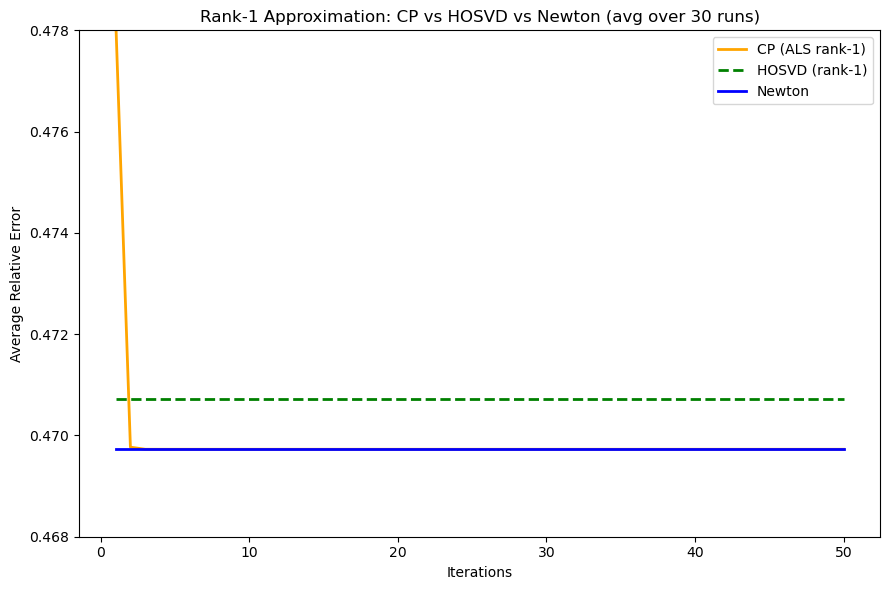

In [190]:
# ── plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
plt.plot(x, cp_avg,     color='orange', linewidth=2, label='CP (ALS rank-1)')
plt.plot(x, hosvd_avg,  color='green',  linewidth=2, label='HOSVD (rank-1)', linestyle='--')
plt.plot(x, newton_avg, color='blue',   linewidth=2, label='Newton')

plt.ylim(0.468, 0.478)
plt.xlabel("Iterations")
plt.ylabel("Average Relative Error")
plt.title("Rank-1 Approximation: CP vs HOSVD vs Newton (avg over 30 runs)")
plt.legend()
plt.tight_layout()
plt.show()

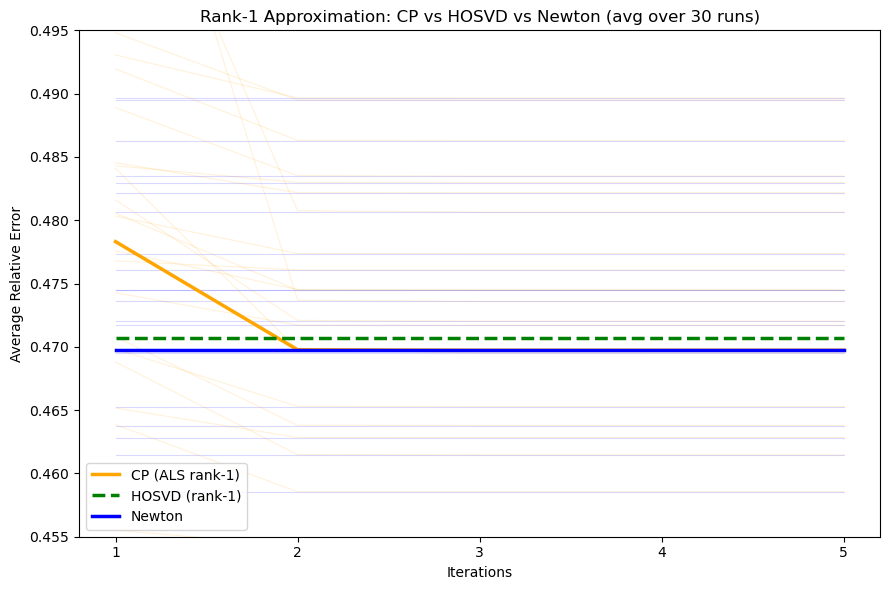

In [193]:
np.random.seed(42)
n_runs, max_iter = 30, 5  # ← reduced to 10 to zoom in on the interesting part

cp_all     = np.zeros((n_runs, max_iter))
hosvd_all  = np.zeros((n_runs, max_iter))
newton_all = np.zeros((n_runs, max_iter))

for r in range(n_runs):
    T = rand_tensor()
    cp_all[r]     = run_cp_iters(T, max_iter)
    hosvd_all[r]  = run_hosvd_flat(T, max_iter)
    newton_all[r] = run_newton_iters(T, max_iter)

cp_avg     = cp_all.mean(axis=0)
hosvd_avg  = hosvd_all.mean(axis=0)
newton_avg = newton_all.mean(axis=0)
x = np.arange(1, max_iter + 1)

plt.figure(figsize=(9, 6))

# individual runs faint in background
for r in range(n_runs):
    plt.plot(x, cp_all[r],     color='orange', alpha=0.15, linewidth=0.8)
    plt.plot(x, newton_all[r], color='blue',   alpha=0.15, linewidth=0.8)

# averages on top
plt.plot(x, cp_avg,     color='orange', linewidth=2.5, label='CP (ALS rank-1)')
plt.plot(x, hosvd_avg,  color='green',  linewidth=2.5, label='HOSVD (rank-1)', linestyle='--')
plt.plot(x, newton_avg, color='blue',   linewidth=2.5, label='Newton')

plt.xticks(range(1, max_iter + 1))
plt.ylim(0.455, 0.495)
plt.xlabel("Iterations")
plt.ylabel("Average Relative Error")
plt.title("Rank-1 Approximation: CP vs HOSVD vs Newton (avg over 30 runs)")
plt.legend()
plt.tight_layout()
plt.show()

In [195]:
import time

# ── bare minimum CP rank-1 decomposition ──────────────────────────
def run_cp(T):
    i, j, k = T.shape
    T1, T2, T3 = flatten(T)
    A = np.random.random((i, 1))
    B = np.random.random((j, 1))
    C = np.random.random((k, 1))
    prev_err = np.inf

    t0 = time.perf_counter()
    for _ in range(50):
        A = optimize_a(T1, B, C)
        B = optimize_b(T2, C, A)
        C = optimize_c(T3, B, A)
        err = np.linalg.norm(T - reconstruct_CP(A,B,C)) / np.linalg.norm(T)
        if abs(prev_err - err) < 1e-6: break
        prev_err = err
    return time.perf_counter() - t0

# ── bare minimum Newton rank-1 decomposition ──────────────────────
def run_newton(T):
    u, v, w = initialize_with_als(T, n_als=20)
    prev_err = np.inf

    t0 = time.perf_counter()
    for _ in range(50):
        u, v, w = newton1(T, u, v, w)
        u_=u/np.linalg.norm(u); v_=v/np.linalg.norm(v); w_=w/np.linalg.norm(w)
        sig = np.einsum('ijk,i,j,k->', T, u_, v_, w_)
        err = np.linalg.norm(T - sig*np.einsum('i,j,k->ijk',u_,v_,w_)) / np.linalg.norm(T)
        if abs(prev_err - err) < 1e-6: break
        prev_err = err
    return time.perf_counter() - t0

# ── benchmark ─────────────────────────────────────────────────────
np.random.seed(42)
n_runs = 100
cp_times, newton_times = [], []

for _ in range(n_runs):
    T = rand_tensor()
    cp_times.append(run_cp(T))
    newton_times.append(run_newton(T))

In [196]:
print(f"Averaged over {n_runs} random (small) tensors\n")
print(f"{'':30s} {'CP':>10}  {'Newton':>10}")
print("="*55)
print(f"{'Avg runtime (ms)':30s} {np.mean(cp_times)*1000:>10.3f}  {np.mean(newton_times)*1000:>10.3f}")
print(f"{'Std runtime (ms)':30s} {np.std(cp_times)*1000:>10.3f}  {np.std(newton_times)*1000:>10.3f}")
print("="*55)

Averaged over 100 random (small) tensors

                                       CP      Newton
Avg runtime (ms)                    1.461       0.422
Std runtime (ms)                    0.658       0.189


In [200]:
def rand_tensor_30():
    i = np.random.randint(20, 30)
    j = np.random.randint(20, 30)
    k = np.random.randint(20, 30)
    return np.random.randint(0, 51, size=(i, j, k)).astype(float)

In [203]:
np.random.seed(42)
n_runs = 100
cp_times, newton_times = [], []

for _ in range(n_runs):
    T = rand_tensor_30()
    cp_times.append(run_cp(T))
    newton_times.append(run_newton(T))

In [206]:
print(f"Averaged over {n_runs} random (medium) tensors\n")
print(f"{'':30s} {'CP':>10}  {'Newton':>10}")
print("="*55)
print(f"{'Avg runtime (ms)':30s} {np.mean(cp_times)*1000:>10.3f}  {np.mean(newton_times)*1000:>10.3f}")
print(f"{'Std runtime (ms)':30s} {np.std(cp_times)*1000:>10.3f}  {np.std(newton_times)*1000:>10.3f}")
print("="*55)

Averaged over 100 random (medium) tensors

                                       CP      Newton
Avg runtime (ms)                    1.285       1.029
Std runtime (ms)                    0.569       0.271


In [205]:
def rand_tensor_50():
    i = np.random.randint(40, 50)
    j = np.random.randint(40, 50)
    k = np.random.randint(40, 50)
    return np.random.randint(0, 51, size=(i, j, k)).astype(float)

In [207]:
np.random.seed(42)
n_runs = 100
cp_times, newton_times = [], []

for _ in range(n_runs):
    T = rand_tensor_50()
    cp_times.append(run_cp(T))
    newton_times.append(run_newton(T))

print(f"Averaged over {n_runs} random (large) tensors\n")
print(f"{'':30s} {'CP':>10}  {'Newton':>10}")
print("="*55)
print(f"{'Avg runtime (ms)':30s} {np.mean(cp_times)*1000:>10.3f}  {np.mean(newton_times)*1000:>10.3f}")
print(f"{'Std runtime (ms)':30s} {np.std(cp_times)*1000:>10.3f}  {np.std(newton_times)*1000:>10.3f}")
print("="*55)

Averaged over 100 random (large) tensors

                                       CP      Newton
Avg runtime (ms)                    2.141       3.306
Std runtime (ms)                    0.499       0.868
